# **Results Comparison**
In this section, the performance of the two approaches (MLP with NASnet and VotingClassifier with Xception feature extraction) is compared using several evaluation metrics, including accuracy, precision, recall, and F1-score. To perform this comparison, the metrics obtained during the experiments were stored in a JSON file, which allows the results to be saved and reused without recomputing the models.

The JSON file containing the metrics for both approaches is then loaded and used to generate visualizations such as bar charts and radar plots. These visualizations help to clearly compare the performance of the models across different evaluation metrics and provide a more intuitive understanding of the differences between the two approaches.

In [28]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Load json Results**

In [29]:
MLP_PATH_BALANCED_BASELINE = "Models\\MLP\\results\\balanced\\evaluation_results_balanced_baseline.json"
MLP_PATH_IMBALANCED_BASELINE = "Models\\MLP\\results\\imbalanced\\evaluation_results_imbalanced_baseline.json"
MLP_PATH_BALANCED_OPTUNA = "Models\\MLP\\results\\balanced\\evaluation_results_balanced_optuna.json"
MLP_PATH_IMBALANCED_OPTUNA = "Models\\MLP\\results\\imbalanced\\evaluation_results_imbalanced_optuna.json"


RF_PATH_BALANCED_BASELINE = "Models\\Random_Forest\\results\\balanced\\evaluation_results_balanced_baseline.json"
RF_PATH_IMBALANCED_BASELINE = "Models\\Random_Forest\\results\\imbalanced\\evaluation_results_imbalanced_baseline.json"
RF_PATH_BALANCED_OPTUNA = "Models\\Random_Forest\\results\\balanced\\evaluation_results_balanced_optuna.json"
RF_PATH_IMBALANCED_OPTUNA = "Models\\Random_Forest\\results\\imbalanced\\evaluation_results_imbalanced_optuna.json"

XGB_PATH_BALANCED_BASELINE = "Models\\XGBoost\\results\\balanced\\evaluation_results_balanced_baseline.json"
XGB_PATH_IMBALANCED_BASELINE = "Models\\XGBoost\\results\\imbalanced\\evaluation_results_imbalanced_baseline.json"
XGB_PATH_BALANCED_OPTUNA = "Models\\XGBoost\\results\\balanced\\evaluation_results_balanced_optuna.json"
XGB_PATH_IMBALANCED_OPTUNA = "Models\\XGBoost\\results\\imbalanced\\evaluation_results_imbalanced_optuna.json"

LR_PATH_BALANCED_BASELINE = "Models\\Logistic_Regression\\results\\balanced\\evaluation_results_balanced_baseline.json"
LR_PATH_IMBALANCED_BASELINE = "Models\\Logistic_Regression\\results\\imbalanced\\evaluation_results_imbalanced_baseline.json"
LR_PATH_BALANCED_OPTUNA = "Models\\Logistic_Regression\\results\\balanced\\evaluation_results_balanced_optuna.json"
LR_PATH_IMBALANCED_OPTUNA = "Models\\Logistic_Regression\\results\\imbalanced\\evaluation_results_imbalanced_optuna.json"


In [30]:
FILES = [
    ("MLP", "Balanced", "Baseline", MLP_PATH_BALANCED_BASELINE),
    ("MLP", "Imbalanced", "Baseline", MLP_PATH_IMBALANCED_BASELINE),
    ("MLP", "Balanced", "Optuna", MLP_PATH_BALANCED_OPTUNA),
    #("MLP", "Imbalanced", "Optuna", MLP_PATH_IMBALANCED_OPTUNA),

    ("RF", "Balanced", "Baseline", RF_PATH_BALANCED_BASELINE),
    ("RF", "Imbalanced", "Baseline", RF_PATH_IMBALANCED_BASELINE),
    ("RF", "Balanced", "Optuna", RF_PATH_BALANCED_OPTUNA),
    #("RF", "Imbalanced", "Optuna", RF_PATH_IMBALANCED_OPTUNA),

    ("XGB", "Balanced", "Baseline", XGB_PATH_BALANCED_BASELINE),
    ("XGB", "Imbalanced", "Baseline", XGB_PATH_IMBALANCED_BASELINE),
    ("XGB", "Balanced", "Optuna", XGB_PATH_BALANCED_OPTUNA),
    ("XGB", "Imbalanced", "Optuna", XGB_PATH_IMBALANCED_OPTUNA),
    
    ("LR", "Balanced", "Baseline", LR_PATH_BALANCED_BASELINE),
    #("LR", "Imbalanced", "Baseline", LR_PATH_IMBALANCED_BASELINE),
    ("LR", "Balanced", "Optuna", LR_PATH_BALANCED_OPTUNA),
    #("LR", "Imbalanced", "Optuna", LR_PATH_IMBALANCED_OPTUNA),
]


In [31]:

rows = []

for model, dataset, optimization, path in FILES:
    with open(path, "r") as f:
        data = json.load(f)
    cm = data["confusion_matrix"]

    tn = cm[0][0]
    fp = cm[0][1]
    fn = cm[1][0]
    tp = cm[1][1]

    rows.append({
        "Model": model,
        "Dataset": dataset,
        "Optimization": optimization,
        "Accuracy": data["accuracy"],
        "Precision": data["precision"],
        "Recall": data["recall"],
        "F1 Score": data["f1_score"],
        "AUC": data["auc"],
        "Inference Time (ms)": data["inference_time_ms"],
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

results_df = pd.DataFrame(rows)

# Optional: round metrics
metric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "AUC",
    "Inference Time (ms)"
]

results_df[metric_cols] = results_df[metric_cols].round(6)

display(results_df)

,Model,Dataset,Optimization,Accuracy,Precision,Recall,F1 Score,AUC,Inference Time (ms),TN,FP,FN,TP
0,MLP,Balanced,Baseline,0.999329,0.999997,0.999330,0.999664,0.999725,52.189329,3909,6,1289,1923693
1,MLP,Imbalanced,Baseline,0.999990,0.999990,1.000000,0.999995,0.998851,68.168311,3895,20,0,1924982
2,MLP,Balanced,Optuna,0.999012,0.999998,0.999012,0.999505,0.999725,58.654944,3911,4,1902,1923080
3,RF,Balanced,Baseline,0.999574,0.999999,0.999574,0.999787,0.999987,1117.721620,3914,1,820,1924162
4,RF,Imbalanced,Baseline,0.999999,0.999999,0.999999,0.999999,1.000000,1320.978480,3914,1,1,1924981
5,RF,Balanced,Optuna,0.999406,0.999999,0.999405,0.999702,0.999976,32.853075,3914,1,1145,1923837
6,XGB,Balanced,Baseline,0.999613,1.000000,0.999612,0.999806,0.999942,196.835970,3915,0,746,1924236
7,XGB,Imbalanced,Baseline,0.999996,0.999997,0.999999,0.999998,1.000000,161.491010,3910,5,2,1924980
8,XGB,Balanced,Optuna,0.999434,0.999999,0.999434,0.999717,0.999950,0.638860,3914,1,1090,1923892
9,XGB,Imbalanced,Optuna,0.999990,0.999995,0.999995,0.999995,1.000000,1.512588,3905,10,10,1924972


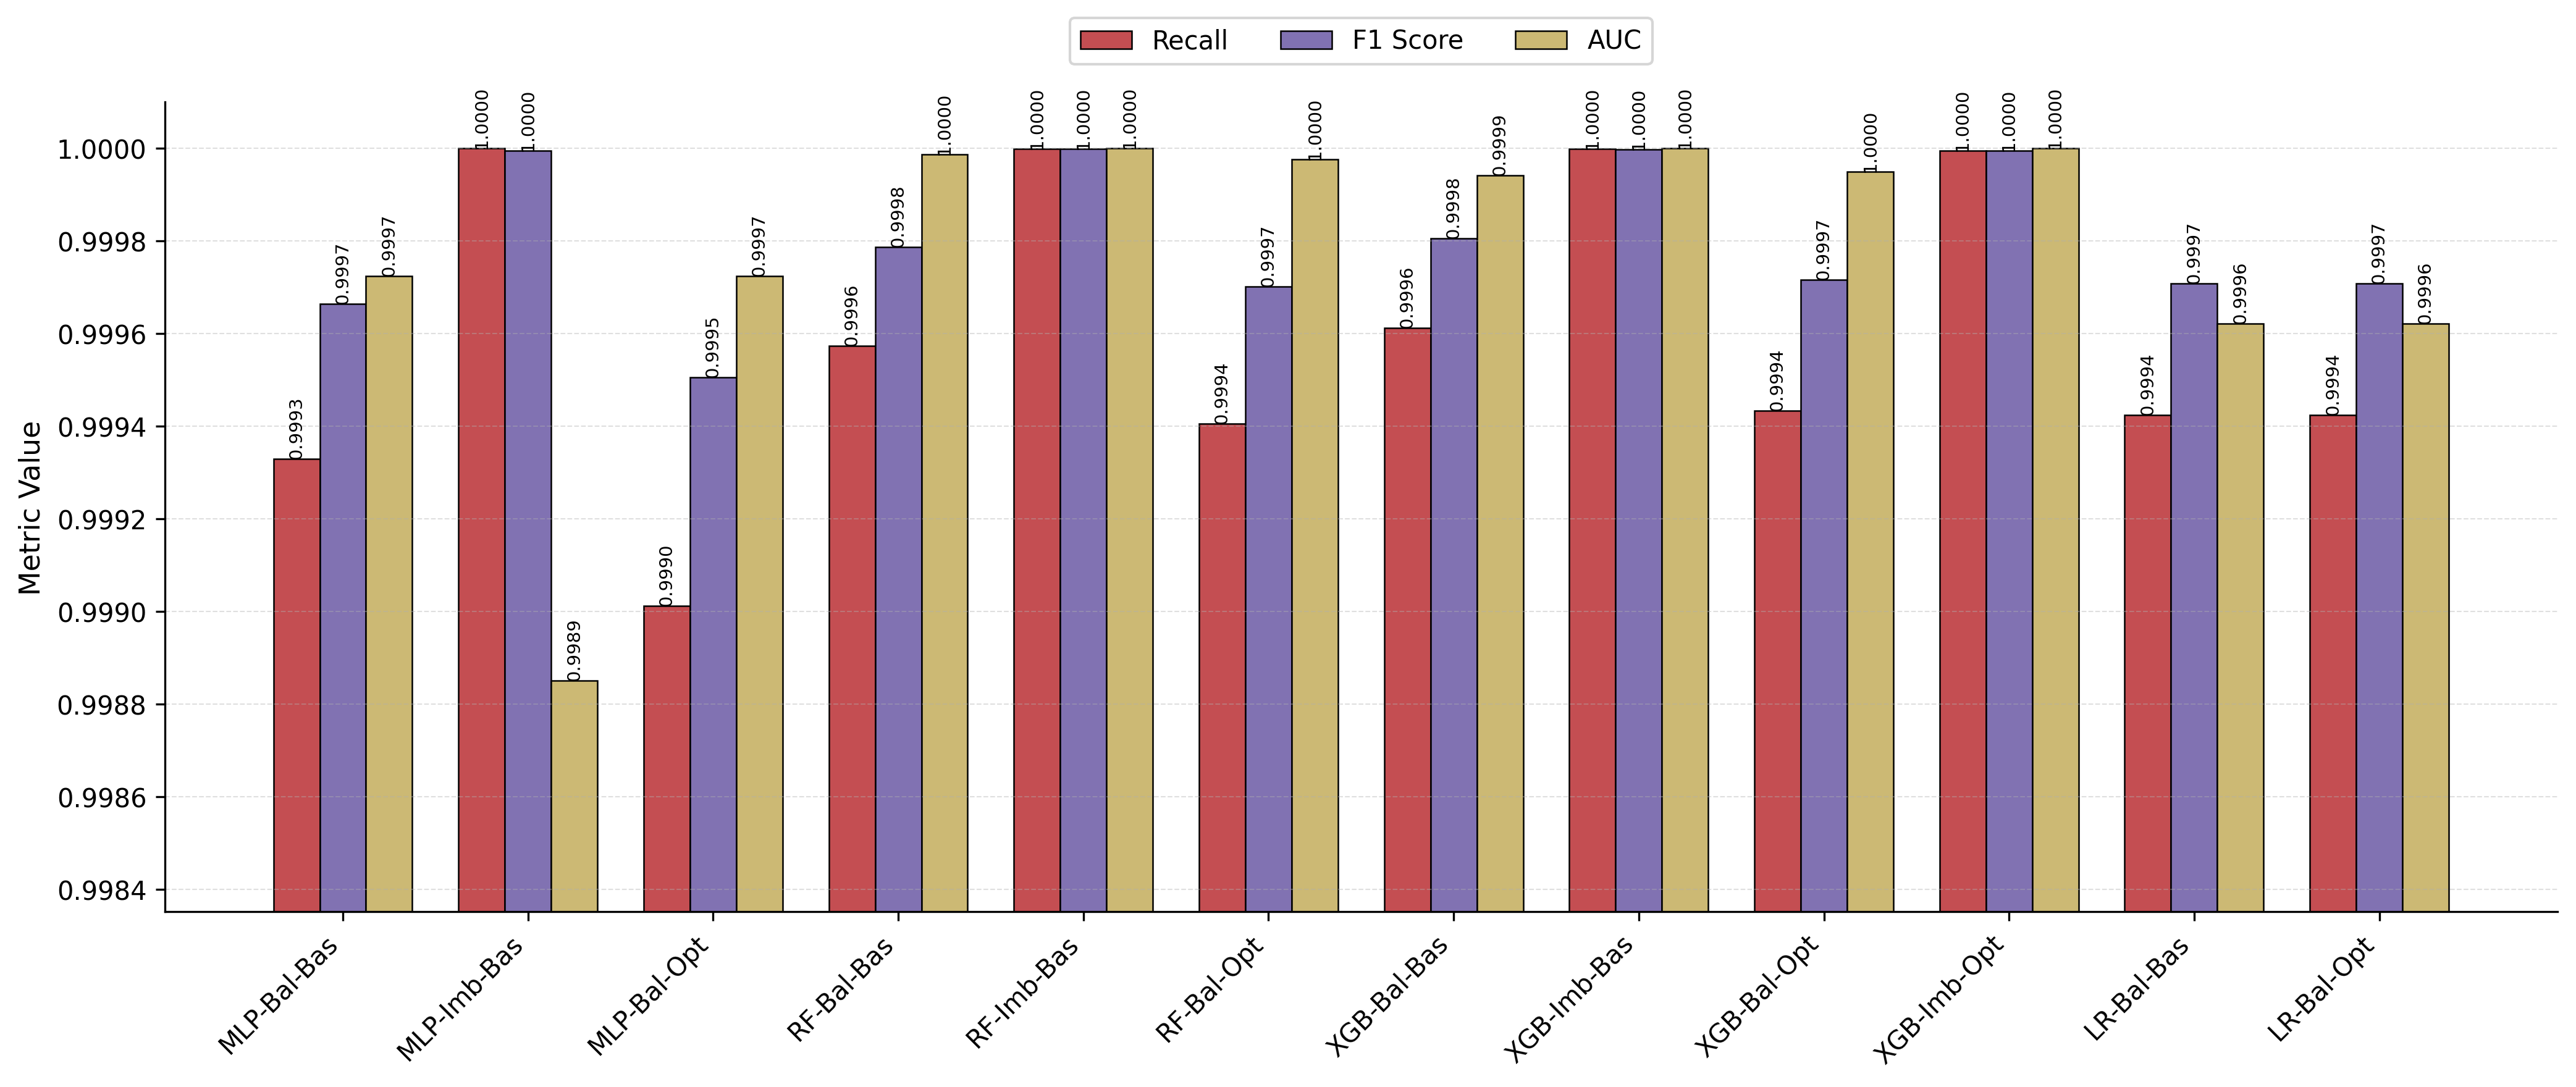

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# Metrics to Compare
# =====================================================

metrics = [
    "Recall",
    "F1 Score",
    "AUC"
]

# =====================================================
# Prepare Data
# =====================================================

plot_df = results_df.copy()

plot_df["Configuration"] = (
    plot_df["Model"]
    + "-"
    + plot_df["Dataset"].str[:3]
    + "-"
    + plot_df["Optimization"].str[:3]
)

x = np.arange(len(plot_df))
width = 0.25

# IEEE-style colors
colors = [
    "#C44E52",  # Recall
    "#8172B2",  # F1 Score
    "#CCB974"   # AUC
]

# =====================================================
# Plot
# =====================================================

fig, ax = plt.subplots(
    figsize=(14, 6),
    dpi=300
)

for i, metric in enumerate(metrics):

    bars = ax.bar(
        x + (i - 1) * width,
        plot_df[metric],
        width,
        label=metric,
        color=colors[i],
        edgecolor="black",
        linewidth=0.6
    )

    # Add value labels
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

# =====================================================
# Formatting
# =====================================================


ax.set_ylabel(
    "Metric Value",
    fontsize=11
)

ax.set_xticks(x)

ax.set_xticklabels(
    plot_df["Configuration"],
    rotation=45,
    ha="right",
    fontsize=10
)

# Zoomed axis
ax.set_ylim(
    plot_df[metrics].min().min() - 0.0005,
    1.0001
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

# Clean IEEE-style look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    frameon=True
)

plt.tight_layout()

plt.show()

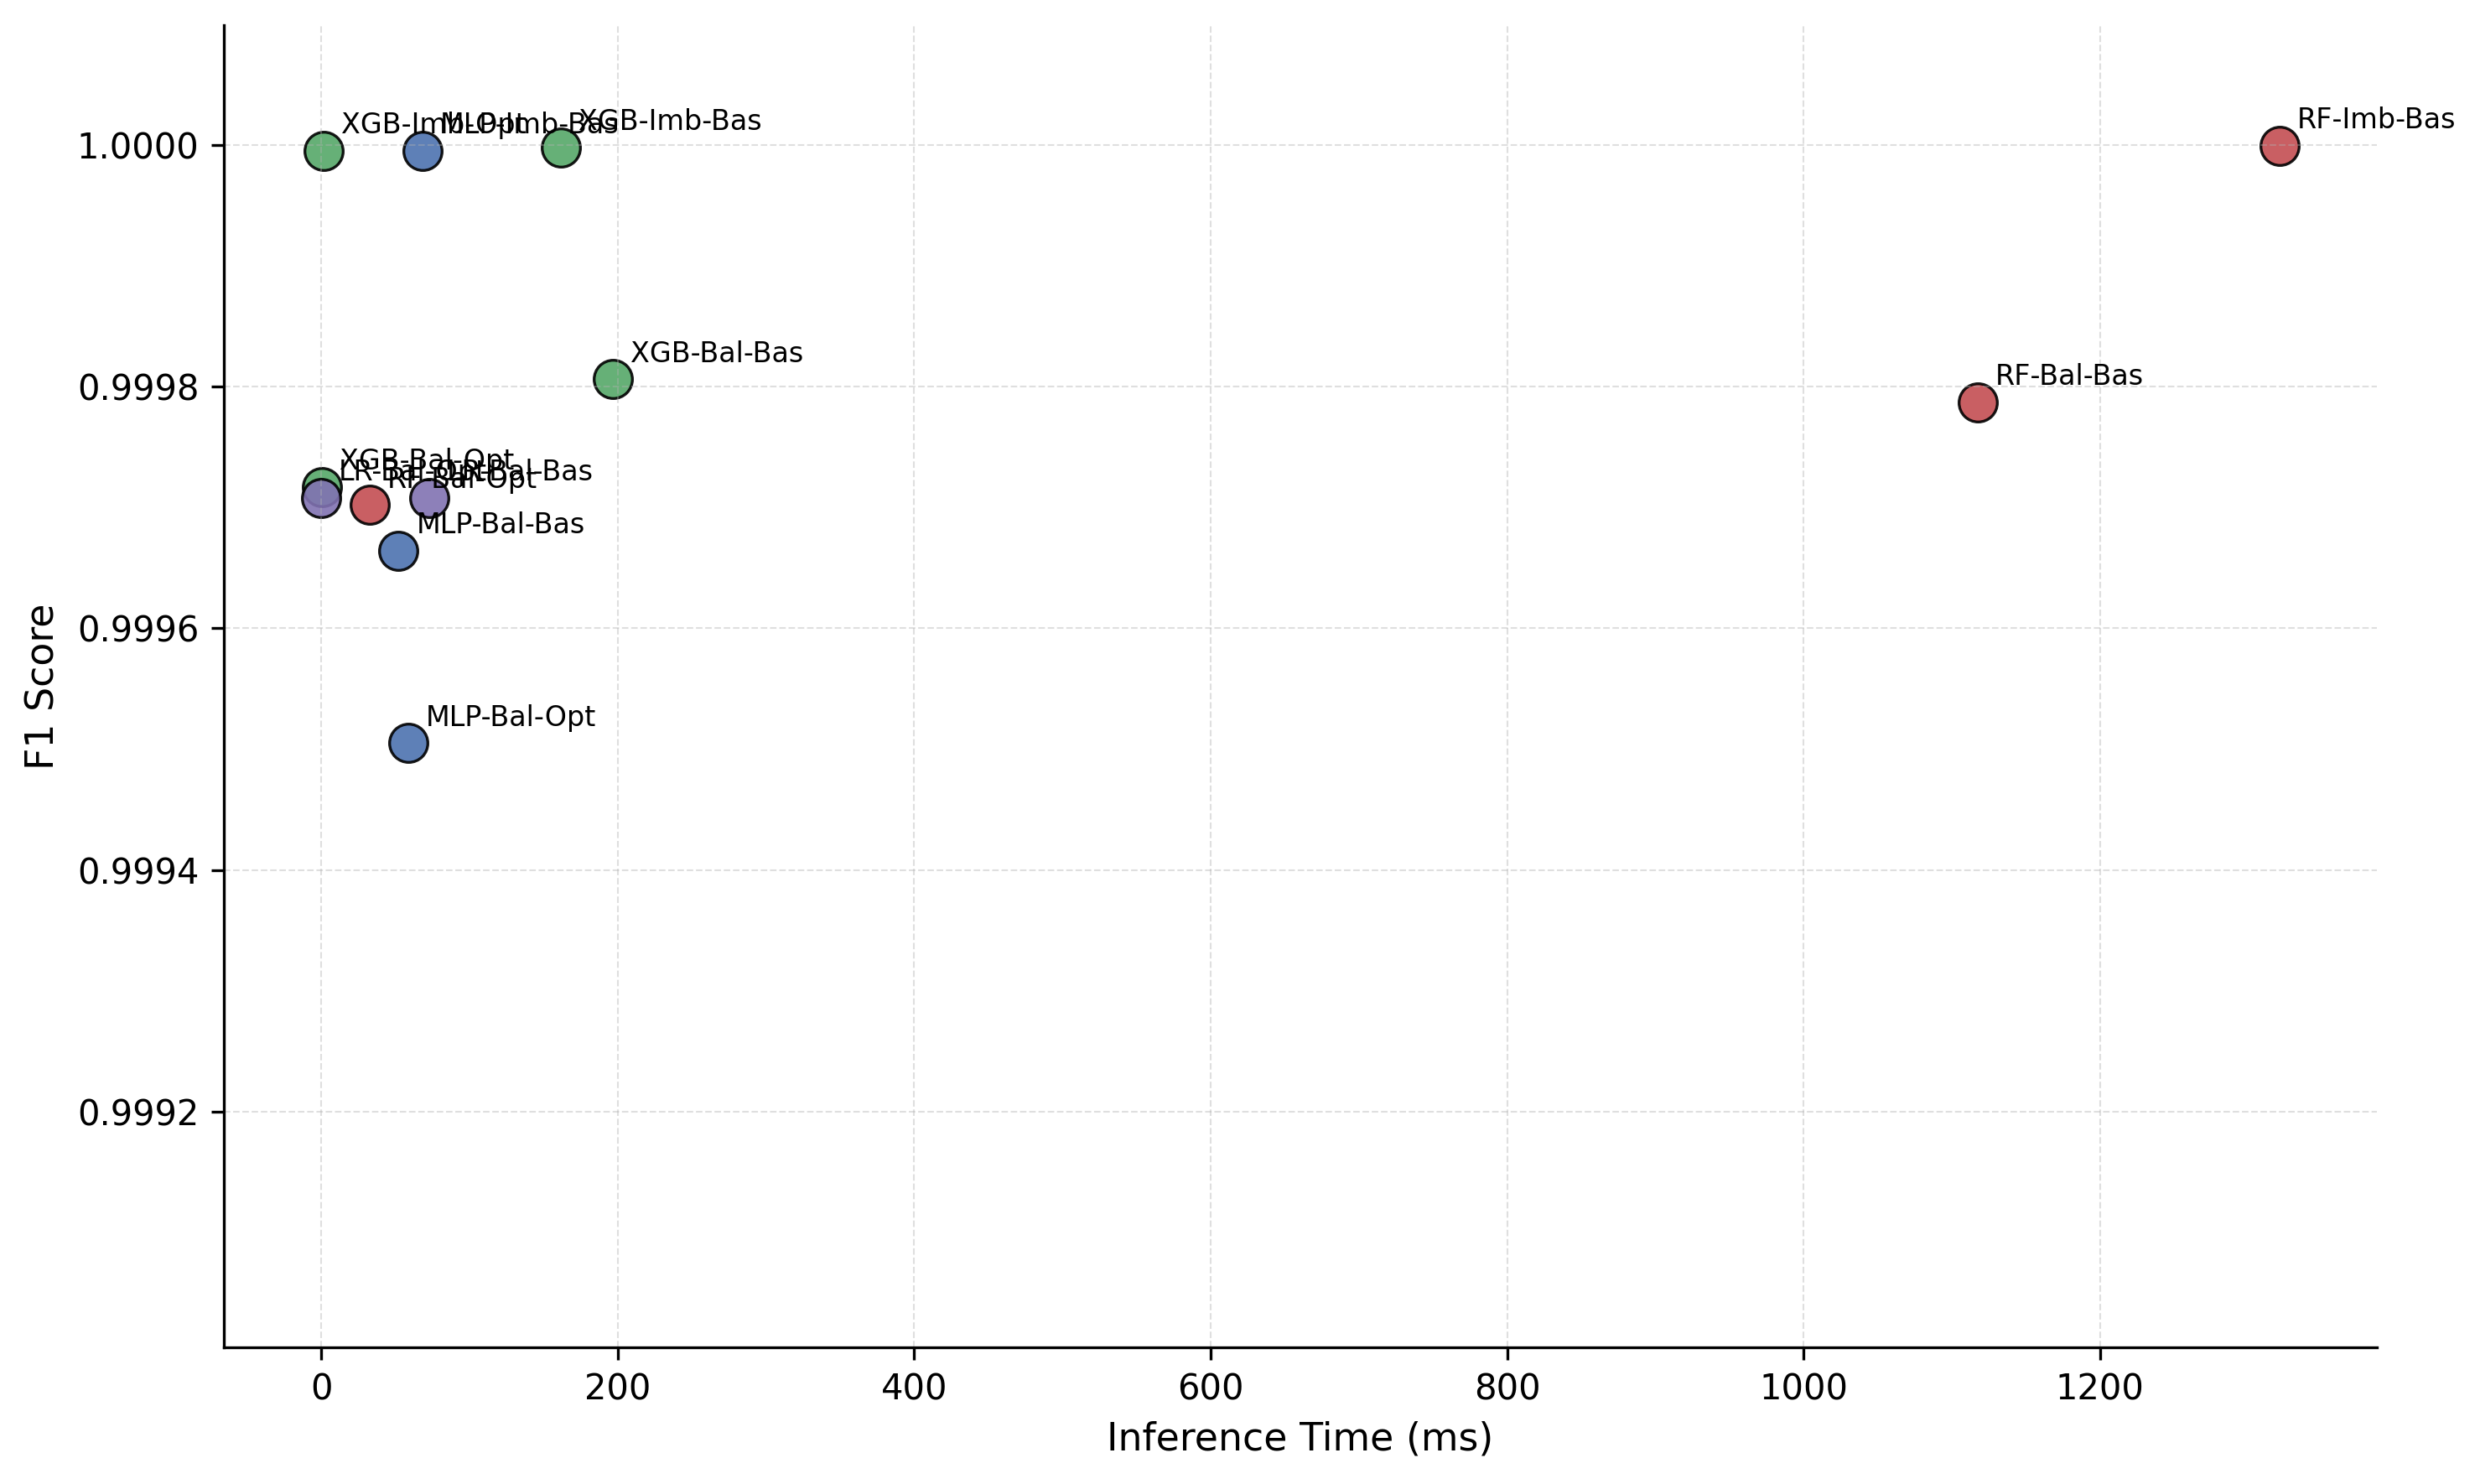

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# IEEE-style model colors
# ==========================================

model_colors = {
    "MLP": "#4C72B0",
    "RF": "#C44E52",
    "XGB": "#55A868",
    "LR": "#8172B2"
}

# ==========================================
# Figure
# ==========================================

fig, ax = plt.subplots(
    figsize=(12, 7),
    dpi=300
)

# Offsets to reduce overlapping labels
offsets = [
    (6, 6),
    (6, -12),
    (-20, 6),
    (-20, -12),
    (10, 15),
    (-25, 15)
]

# ==========================================
# Scatter plot
# ==========================================

for i, (_, row) in enumerate(results_df.iterrows()):

    color = model_colors.get(
        row["Model"],
        "#4C72B0"
    )

    label = (
        f"{row['Model']}-"
        f"{row['Dataset'][:3]}-"
        f"{row['Optimization'][:3]}"
    )

    ax.scatter(
        row["Inference Time (ms)"],
        row["F1 Score"],
        s=180,
        color=color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.9,
        zorder=3
    )

    dx, dy = offsets[i % len(offsets)]

    ax.annotate(
        label,
        (
            row["Inference Time (ms)"],
            row["F1 Score"]
        ),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9
    )

# ==========================================
# Formatting
# ==========================================

ax.set_xlabel(
    "Inference Time (ms, log scale)",
    fontsize=12
)

ax.set_ylabel(
    "F1 Score",
    fontsize=12
)

ax.set_title(
    "Model Performance Comparison",
    fontsize=14,
    weight="bold"
)

# ------------------------------------------
# Log scale for inference time
# ------------------------------------------

ax.set_xscale("log")

# ------------------------------------------
# Zoom around smallest F1
# ------------------------------------------

y_min = results_df["F1 Score"].min()
y_max = results_df["F1 Score"].max()

epsilon = max(
    (y_max - y_min) * 0.20,
    0.00002
)

ax.set_ylim(
    y_min - epsilon,
    y_max + epsilon
)

# ------------------------------------------
# Grid
# ------------------------------------------

ax.grid(
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

# ------------------------------------------
# IEEE style
# ------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------
# Legend
# ------------------------------------------

handles = []

for model, color in model_colors.items():
    handles.append(
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=model,
            markerfacecolor=color,
            markeredgecolor="black",
            markersize=8
        )
    )

ax.legend(
    handles=handles,
    title="Model",
    frameon=False
)

plt.tight_layout()
plt.show()

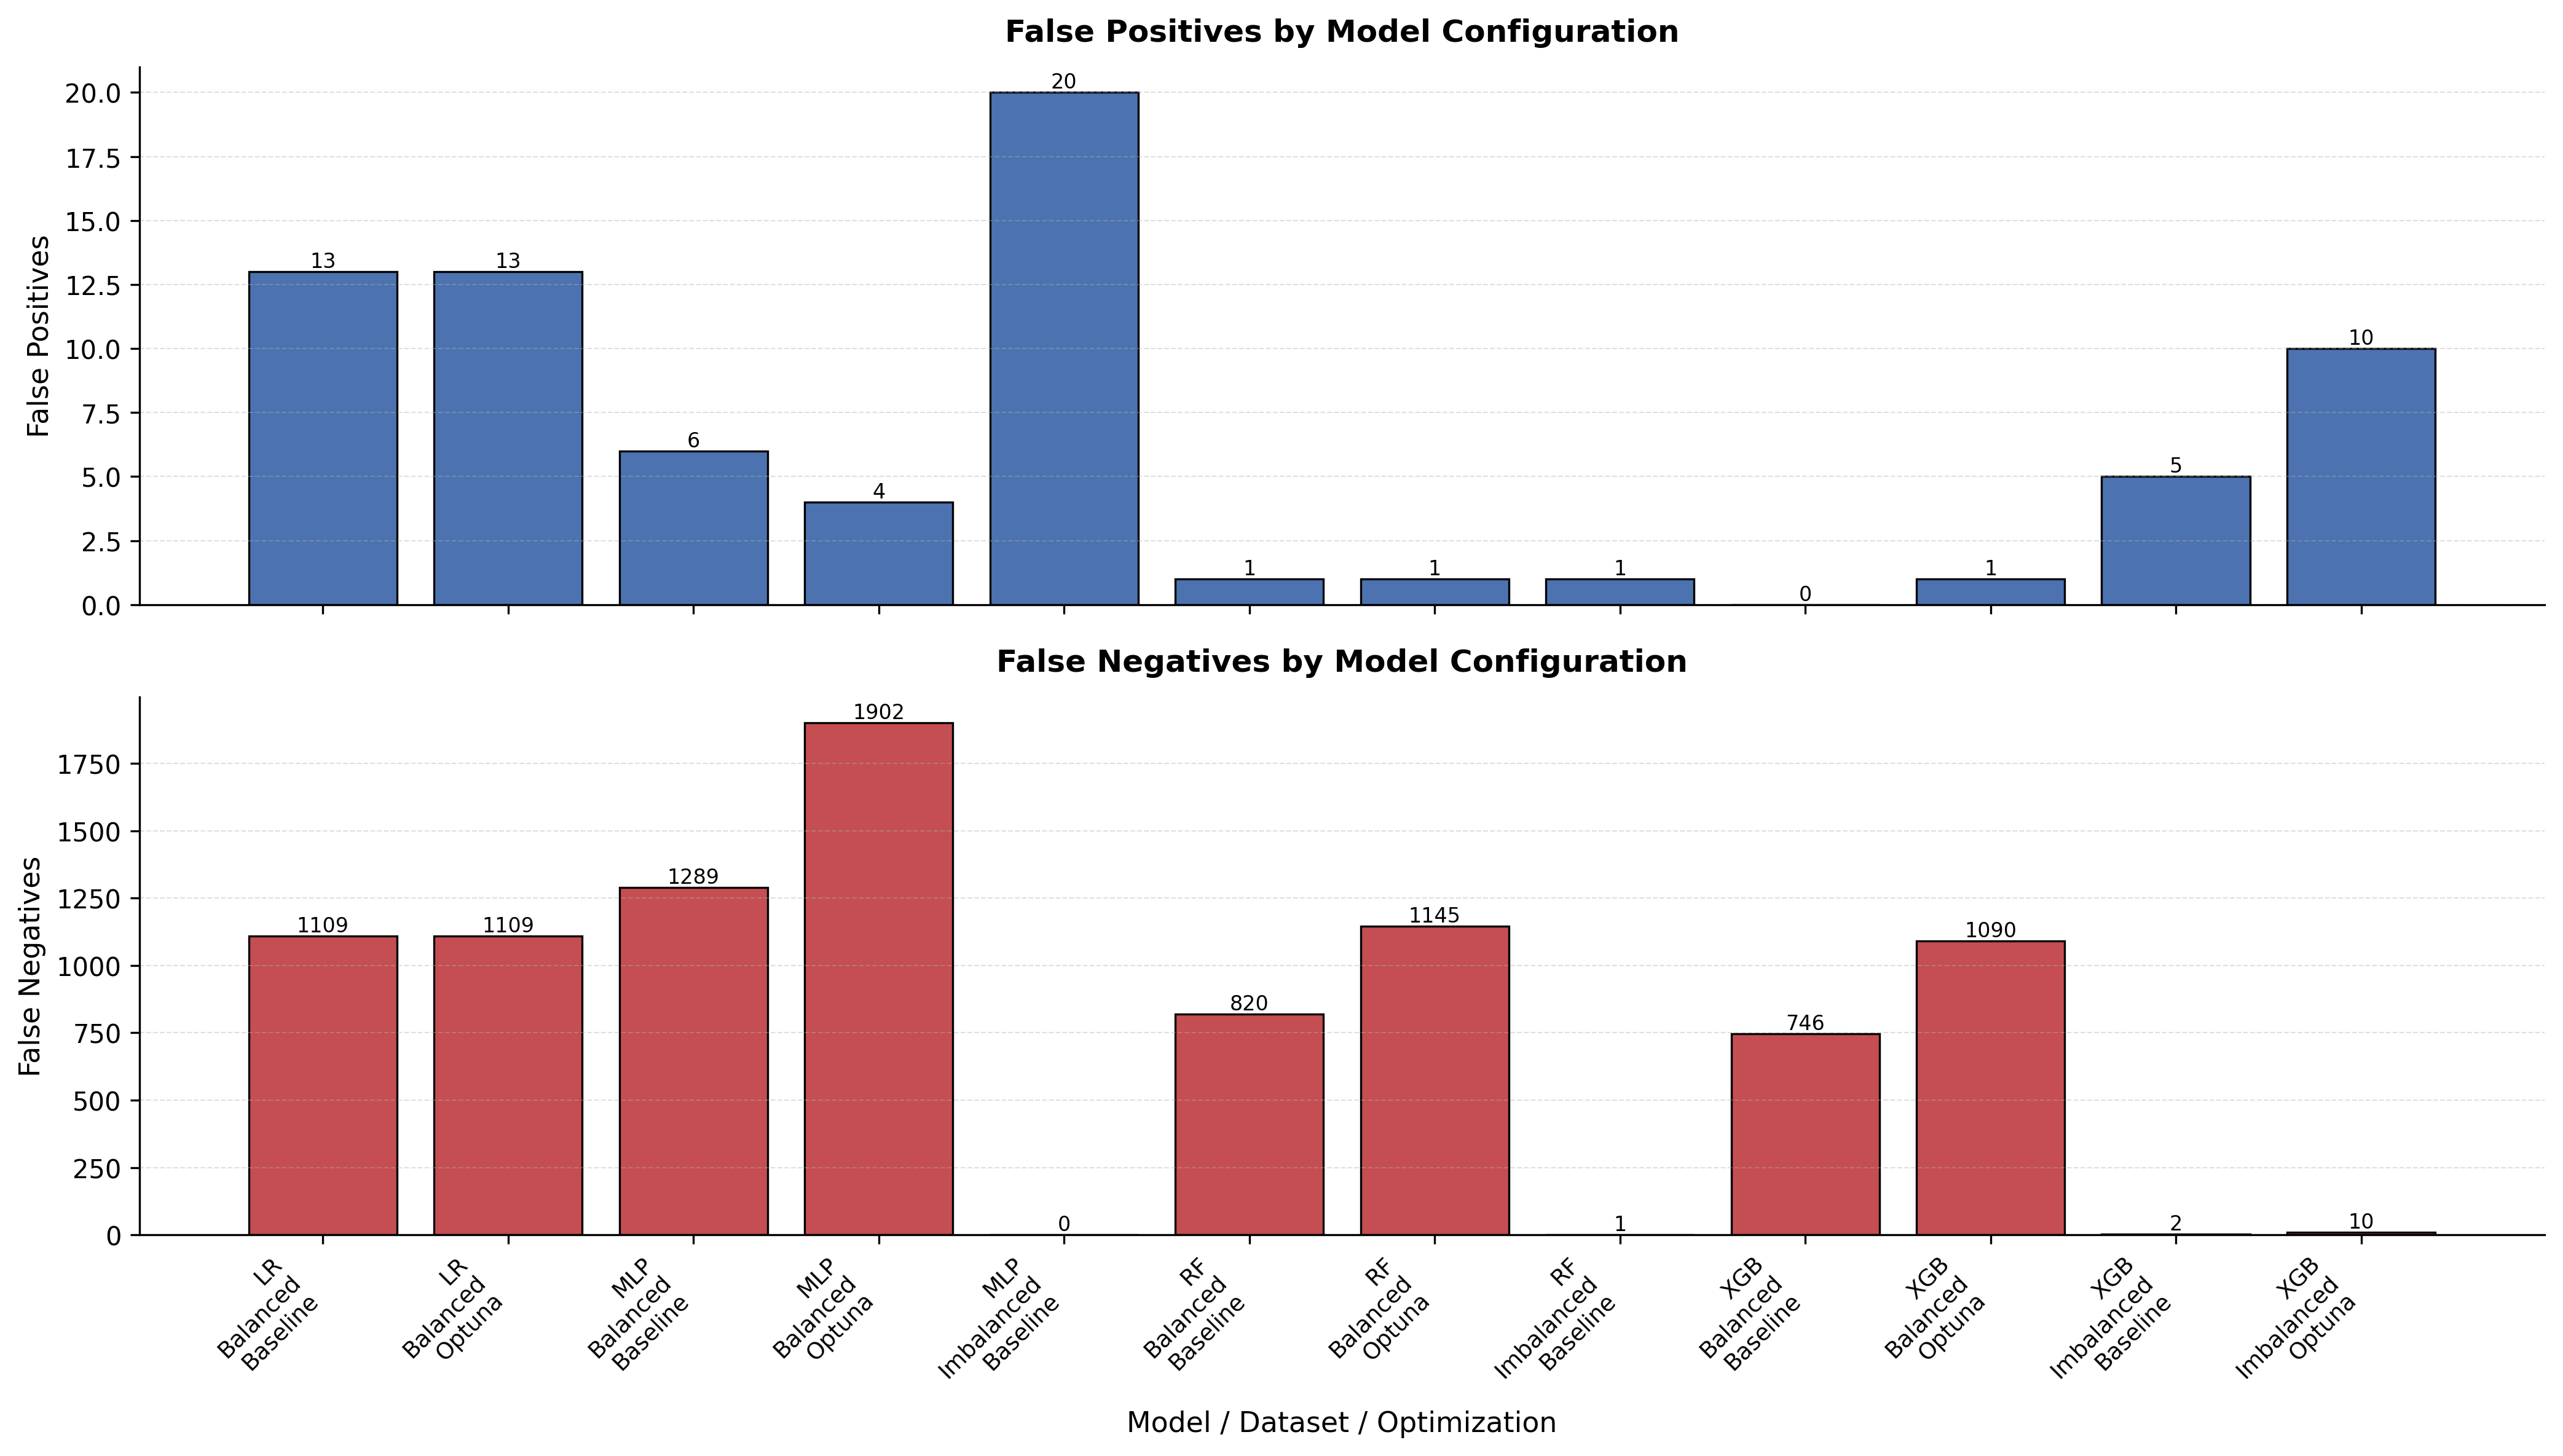

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# IEEE-style colors
# =====================================================

FP_COLOR = "#4C72B0"   # Muted blue
FN_COLOR = "#C44E52"   # Muted red

# =====================================================
# Prepare Data
# =====================================================

plot_df = results_df.copy()

plot_df["Configuration"] = (
    plot_df["Model"]
    + "\n"
    + plot_df["Dataset"]
    + "\n"
    + plot_df["Optimization"]
)

# Optional: sort for cleaner visualization
plot_df = plot_df.sort_values(
    ["Model", "Dataset", "Optimization"]
).reset_index(drop=True)

x = np.arange(len(plot_df))

# =====================================================
# Figure
# =====================================================

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True,
    dpi=300
)

# =====================================================
# False Positives
# =====================================================

bars_fp = ax1.bar(
    x,
    plot_df["FP"],
    color=FP_COLOR,
    edgecolor="black",
    linewidth=0.8
)

ax1.set_title(
    "False Positives by Model Configuration",
    fontsize=12,
    fontweight="bold",
    pad=10
)

ax1.set_ylabel(
    "False Positives",
    fontsize=11
)

ax1.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Value labels
for bar in bars_fp:
    height = bar.get_height()

    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# =====================================================
# False Negatives
# =====================================================

bars_fn = ax2.bar(
    x,
    plot_df["FN"],
    color=FN_COLOR,
    edgecolor="black",
    linewidth=0.8
)

ax2.set_title(
    "False Negatives by Model Configuration",
    fontsize=12,
    fontweight="bold",
    pad=10
)

ax2.set_ylabel(
    "False Negatives",
    fontsize=11
)

ax2.set_xlabel(
    "Model / Dataset / Optimization",
    fontsize=11
)

ax2.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Value labels
for bar in bars_fn:
    height = bar.get_height()

    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# =====================================================
# X-axis Labels
# =====================================================

ax2.set_xticks(x)

ax2.set_xticklabels(
    plot_df["Configuration"],
    rotation=45,
    ha="right",
    fontsize=9
)

# =====================================================
# Layout
# =====================================================



plt.tight_layout()

plt.show()

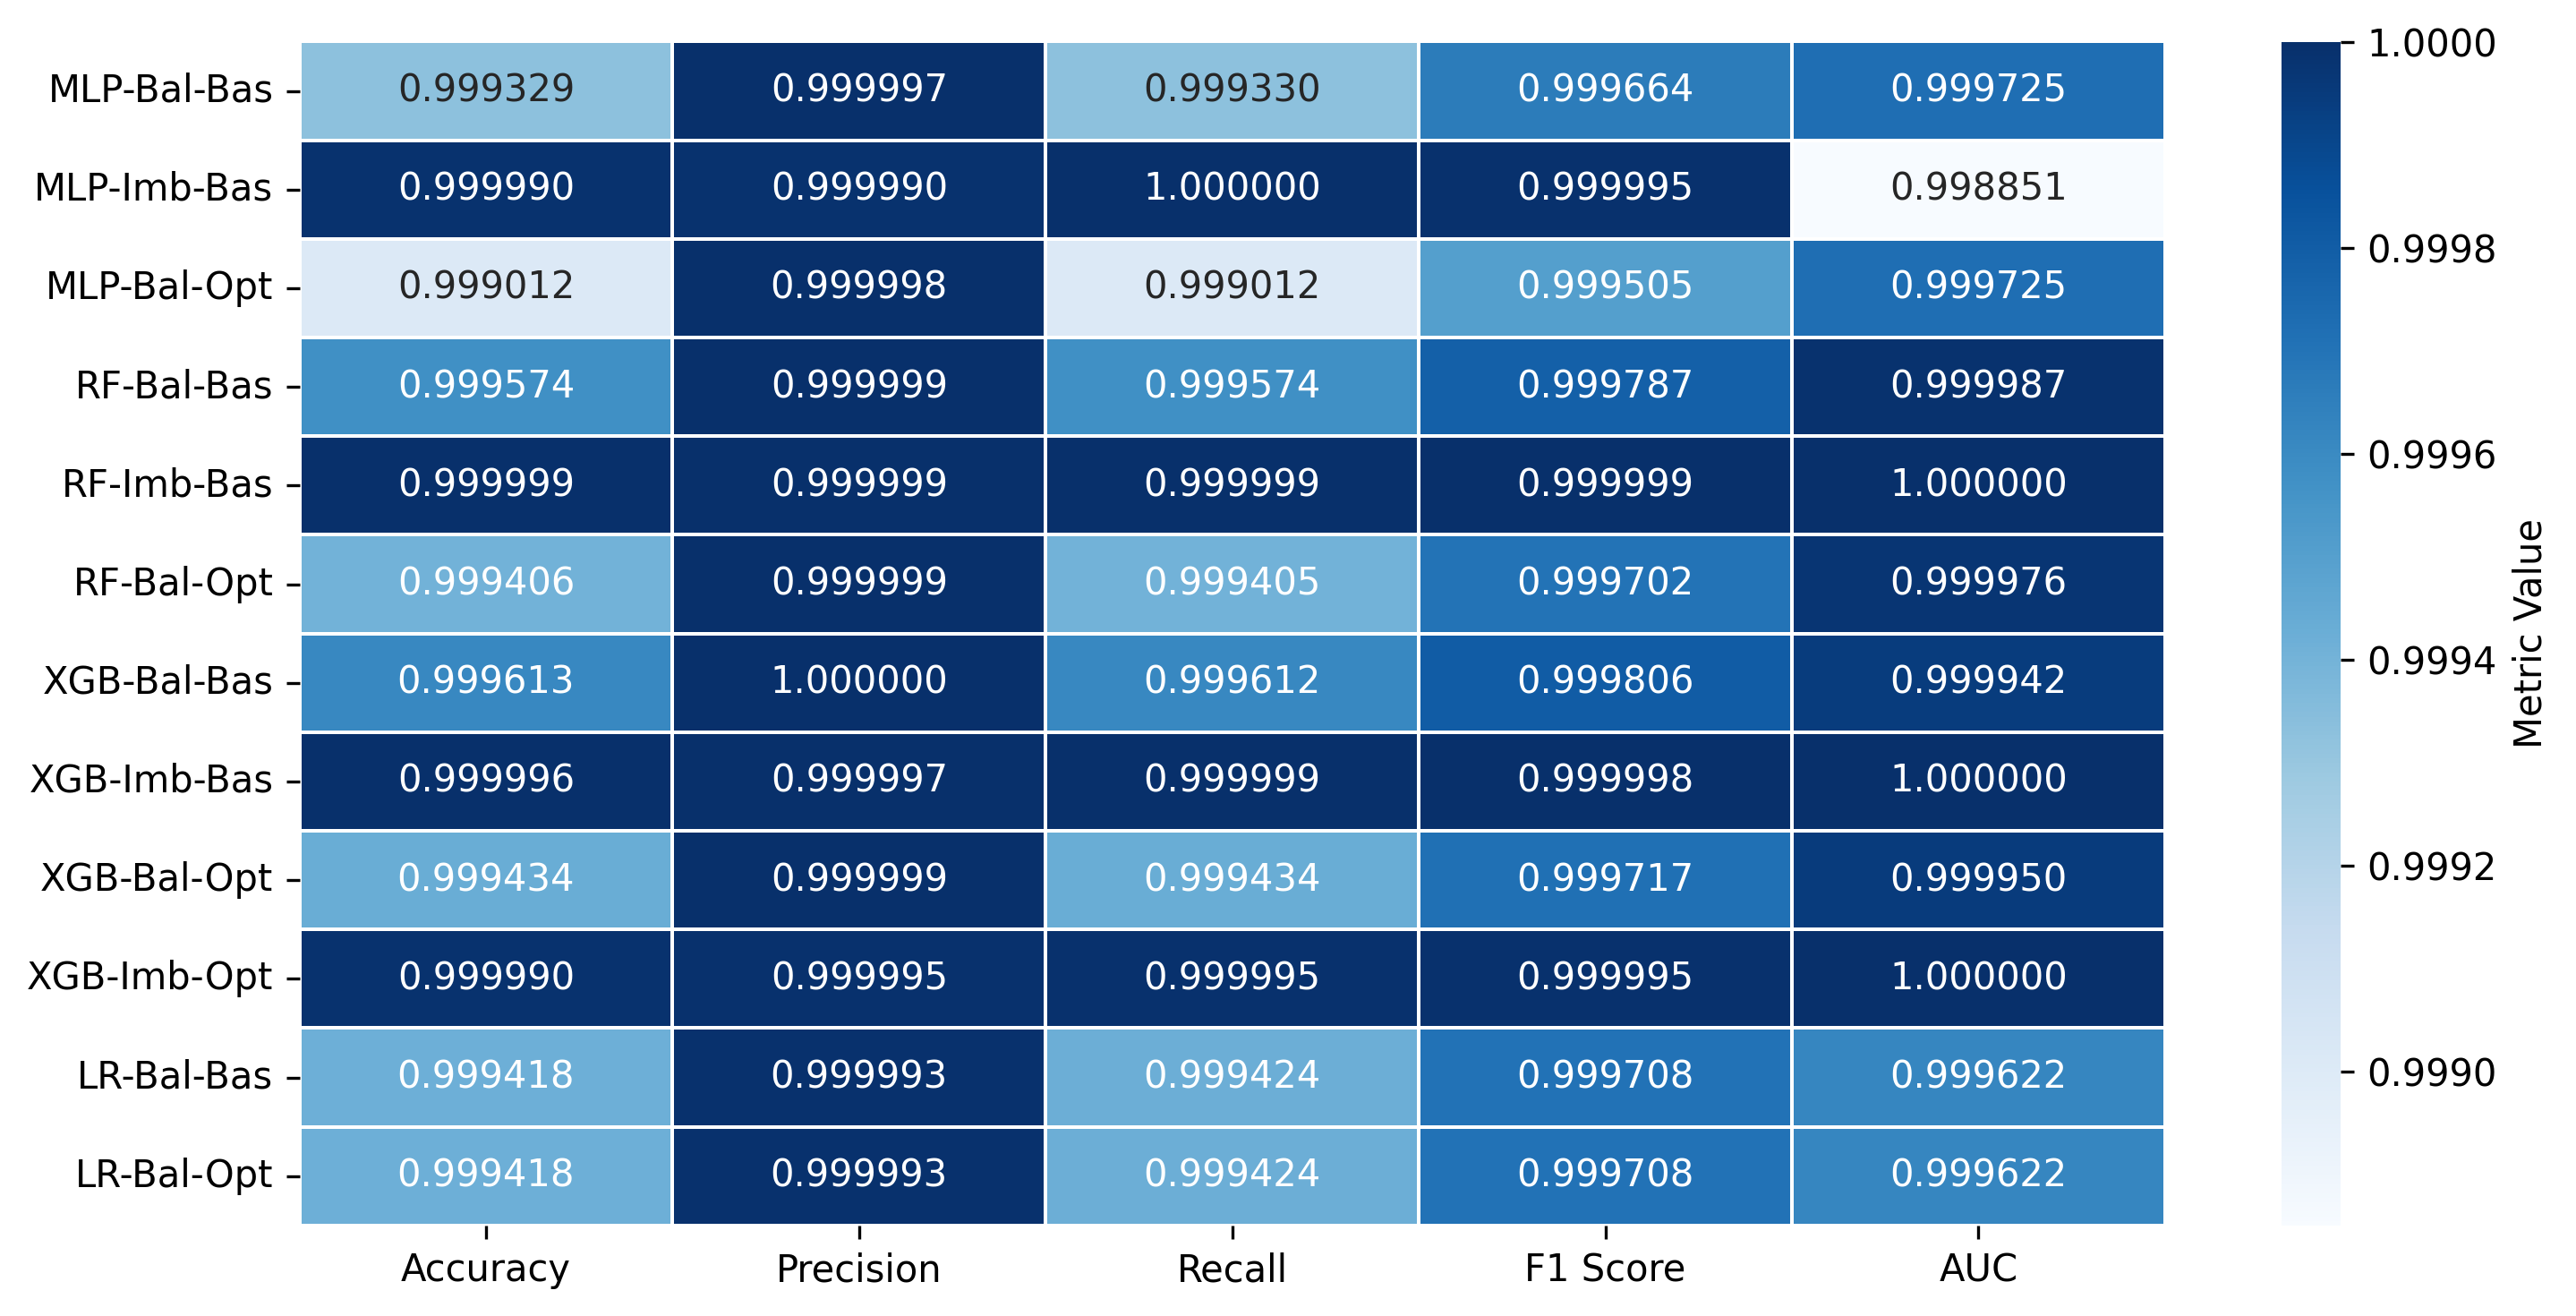

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================
# Prepare Data
# =====================================================

heatmap_df = results_df.copy()

heatmap_df["Configuration"] = (
    heatmap_df["Model"]
    + "-"
    + heatmap_df["Dataset"].str[:3]
    + "-"
    + heatmap_df["Optimization"].str[:3]
)

heatmap_df = heatmap_df.set_index("Configuration")

heatmap_metrics = heatmap_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ]
]

# =====================================================
# Plot
# =====================================================

plt.figure(
    figsize=(10, 5),
    dpi=300
)

sns.heatmap(
    heatmap_metrics,
    annot=True,
    fmt=".6f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",

    # Important for your metrics
    vmin=heatmap_metrics.min().min(),
    vmax=heatmap_metrics.max().max(),

    cbar_kws={
        "label": "Metric Value"
    }
)



plt.xlabel("")
plt.ylabel("")

plt.xticks(
    rotation=0,
    fontsize=10
)

plt.yticks(
    rotation=0,
    fontsize=10
)

plt.tight_layout()

plt.show()